# scRNA-seq Analysis: QC and Annotation
This notebook performs standard quality control (QC), preprocessing, and cell type annotation for single-cell RNA-seq data.

In [2]:
# Import required libraries
import pandas as pd
import scipy.io
import scipy.sparse
import numpy as np

## Load Data
Load the 10X Genomics data into an AnnData object for analysis.

In [3]:
# Load barcodes, features, and matrix
barcodes = pd.read_csv('data/barcodes.tsv.gz', header=None)[0].tolist()
features = pd.read_csv('data/features.tsv.gz', sep='	', header=None)
matrix = scipy.io.mmread('data/matrix.mtx.gz').tocsc()

## Quality Control (QC)
Calculate QC metrics and filter out low-quality cells and genes.

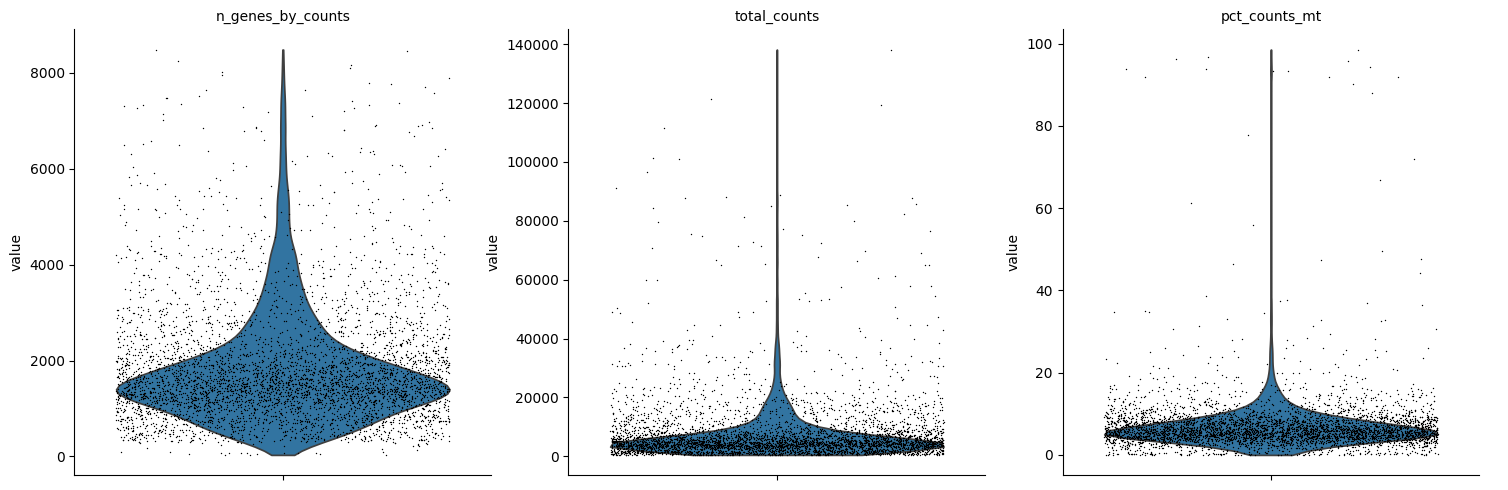

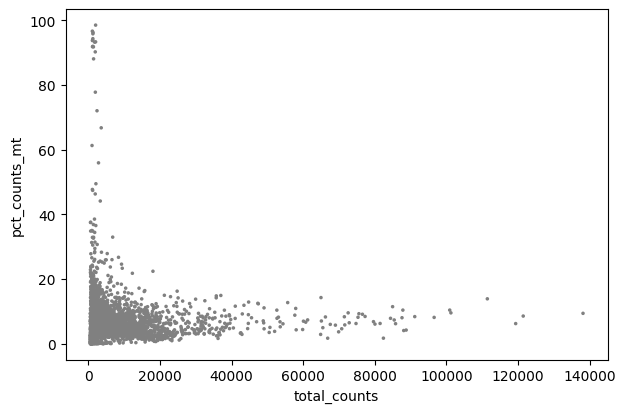

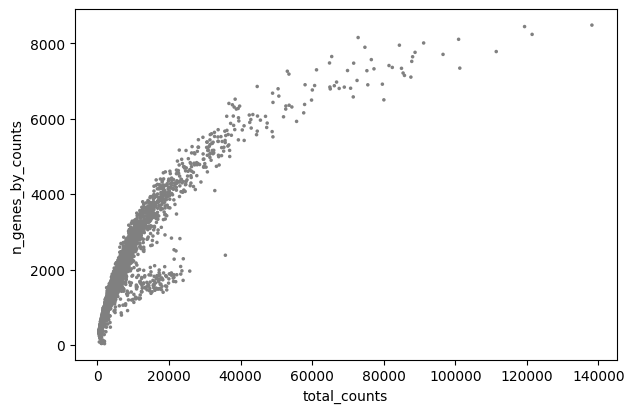

In [4]:
# Load data into AnnData
import scanpy as sc
adata = sc.read_10x_mtx('data/', var_names='gene_symbols', cache=True)

# Calculate QC metrics
adata.var['mt'] = adata.var_names.str.upper().str.startswith('MT-')
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

# Plot QC metrics
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'], jitter=0.4, multi_panel=True)
sc.pl.scatter(adata, x='total_counts', y='pct_counts_mt')
sc.pl.scatter(adata, x='total_counts', y='n_genes_by_counts')

# Filter cells and genes
adata = adata[adata.obs.n_genes_by_counts > 200, :]
adata = adata[adata.obs.pct_counts_mt < 10, :]
adata = adata[:, adata.var.n_cells_by_counts > 3]

## Preprocessing
Normalize, log-transform, and identify highly variable genes for downstream analysis.

In [5]:
# Normalize, log-transform, and find highly variable genes
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=2000)
adata = adata[:, adata.var['highly_variable']]
sc.pp.scale(adata, max_value=10)

/var/folders/m5/1lmcwjqx5635qbdndqcg_x7w0000gn/T/ipykernel_39069/744585903.py:2: UserWarning: Received a view of an AnnData. Making a copy.
  sc.pp.normalize_total(adata, target_sum=1e4)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/functools.py:982: UserWarning: Received a view of an AnnData. Making a copy.
  return dispatch(args[0].__class__)(*args, **kw)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/functools.py:982: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


## Cell Type Annotation with CellTypist
We will use CellTypist to automatically annotate each cell with a predicted cell type based on reference models.

In [ ]:
# Annotate each cell using CellTypist
import celltypist
import scanpy as sc
import numpy as np

# CellTypist expects log1p normalized data to 10,000 counts per cell
# Remove any cells or genes with NaN or infinite values before running CellTypist
adata_ct = adata.copy()

# Remove cells with any NaN or inf values
cell_mask = ~np.isnan(adata_ct.X).any(axis=1) & ~np.isinf(adata_ct.X).any(axis=1)
adata_ct = adata_ct[cell_mask, :]
# Remove genes with any NaN or inf values
gene_mask = ~np.isnan(adata_ct.X).any(axis=0) & ~np.isinf(adata_ct.X).any(axis=0)
adata_ct = adata_ct[:, gene_mask]

sc.pp.normalize_total(adata_ct, target_sum=1e4)
sc.pp.log1p(adata_ct)

# Double-check for any remaining NaNs or infs
if np.isnan(adata_ct.X).any() or np.isinf(adata_ct.X).any():
    import warnings
    warnings.warn("adata_ct.X still contains NaN or inf values after cleaning. These cells/genes will be skipped in annotation.")
    # Optionally, you could drop remaining problematic cells/genes here

# Download and load the default CellTypist model
model = celltypist.models.Model.load("Immune_All_Low.pkl")

# Run CellTypist prediction
predictions = celltypist.annotate(adata_ct, model=model, majority_voting=True)

# Map predictions back to original AnnData by index
adata.obs['celltypist_label'] = np.nan
adata.obs.loc[adata_ct.obs_names, 'celltypist_label'] = predictions.predicted_labels.values

# Output: DataFrame with cell barcodes and predicted cell types
celltype_df = adata.obs[['celltypist_label']]
celltype_df.head()

ValueError: adata_ct.X still contains NaN or inf values after cleaning. Please check your input data.